In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from source_code.itransformer_dataset import load_and_preprocess_data
import pandas as pd

In [3]:
# --- Step A: Load Data ---
# 1. Load Data
(
    df_1,
    df_all,
    hist_exog_cols_1,
    time_exog_cols,
    target_col_1,
    all_target,
) = load_and_preprocess_data('/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/max_planck_weather_ts.csv')

1. Membaca dan memproses dataset multivariate...
✅ Preprocessing selesai:
   - df_1  (1 target)   : (70129, 20) | unique_id: 1
   - df_all (14 target)  : (981806, 7) | unique_id: 14


In [4]:
# --- Step B: Train-Test Split (Long Format) ---
HORIZON = 24  # Prediksi 144 jam ke depan
INPUT_SIZE = 48  # Lookback 288 jam ke belakang

NUM_TIMESTAMPS = 10000  # Total timestamp yang digunakan
TEST_TIMESTAMPS = 2000  # Timestamp untuk pengujian

# =====================================================================
# SKENARIO 1: DATASET 1 TARGET (Suhu T)
# =====================================================================
NUM_TARGETS_1 = len(target_col_1)  # 1 Target

# Ambil 10.000 timestamp terakhir berbasis kolom 'ds'
unique_ds_1 = df_1['ds'].unique()[-NUM_TIMESTAMPS:]
df_sample_1 = df_1[df_1['ds'].isin(unique_ds_1)].reset_index(drop=True)

# Split Train & Test
last_train_ds_1 = unique_ds_1[-TEST_TIMESTAMPS]
train_df_1 = df_sample_1[df_sample_1['ds'] < last_train_ds_1].copy()
test_df_1 = df_sample_1[df_sample_1['ds'] >= last_train_ds_1].copy()

print(
    f'Informasi Dataset 1 Target:\n'
    f'- Jumlah Fitur Target  : {NUM_TARGETS_1} fitur ({target_col_1[0]})\n'
    f'- Timestep Train Data  : {len(train_df_1) // NUM_TARGETS_1} baris\n'
    f'- Timestep Test Data   : {len(test_df_1) // NUM_TARGETS_1} baris\n'
)

# =====================================================================
# SKENARIO 2: DATASET ALL TARGETS (14 Fitur Cuaca)
# =====================================================================
NUM_TARGETS_ALL = len(all_target)  # 14 Target

# Ambil 10.000 timestamp terakhir berbasis kolom 'ds' untuk SEMUA unique_id
unique_ds_all = df_all['ds'].unique()[-NUM_TIMESTAMPS:]
df_sample_all = df_all[df_all['ds'].isin(unique_ds_all)].reset_index(
    drop=True
)

# Split Train & Test
last_train_ds_all = unique_ds_all[-TEST_TIMESTAMPS]
train_df_all = df_sample_all[df_sample_all['ds'] < last_train_ds_all].copy()
test_df_all = df_sample_all[df_sample_all['ds'] >= last_train_ds_all].copy()

print(
    f'Informasi Dataset All Target:\n'
    f'- Jumlah Fitur Target  : {NUM_TARGETS_ALL} fitur\n'
    f'- Timestep Train Data  : {len(train_df_all) // NUM_TARGETS_ALL} baris per fitur\n'
    f'- Timestep Test Data   : {len(test_df_all) // NUM_TARGETS_ALL} baris per fitur'
)

Informasi Dataset 1 Target:
- Jumlah Fitur Target  : 1 fitur (T (degC))
- Timestep Train Data  : 8000 baris
- Timestep Test Data   : 2000 baris

Informasi Dataset All Target:
- Jumlah Fitur Target  : 14 fitur
- Timestep Train Data  : 8000 baris per fitur
- Timestep Test Data   : 2000 baris per fitur


# **Eksperimen 1: Single Target Benchmark (Fokus 1 Target: Suhu)**

In [5]:
import os
from neuralforecast import NeuralForecast
from neuralforecast.models import GRU, DLinear, NHITS, PatchTST, iTransformer

# 1. Inisialisasi Model untuk Eksperimen 1 (Dataset 1 Target)
models_exp1 = [
    iTransformer(
        h=HORIZON,
        input_size=INPUT_SIZE,
        n_series=1,
        #futr_exog_list=time_exog_cols,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
    PatchTST(
        h=HORIZON,
        input_size=INPUT_SIZE,
        n_series=1,
        #futr_exog_list=time_exog_cols,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
    DLinear(
        h=HORIZON,
        input_size=INPUT_SIZE,
        #hist_exog_list=hist_exog_cols_1,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
    NHITS(
        h=HORIZON,
        input_size=INPUT_SIZE,
        hist_exog_list=hist_exog_cols_1,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
    GRU(
        h=HORIZON,
        input_size=INPUT_SIZE,
        hist_exog_list=hist_exog_cols_1,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
]

# 2. Fit & Save Model Eksperimen 1
nf_exp1 = NeuralForecast(models=models_exp1, freq='h')
print('=== TRARINING EKSPERIMEN 1 (1 TARGET) ===')
VAL_SIZE = 24
nf_exp1.fit(df=train_df_1, val_size=VAL_SIZE)

path_exp1 = '/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/max_plank_weather/all_models_training/models_exp1'
nf_exp1.save(path=path_exp1, overwrite=True)

# 3. Predict / Cross Validation
cv_exp1 = nf_exp1.cross_validation(
    df=df_sample_1,
    n_windows=TEST_TIMESTAMPS // HORIZON,
    val_size=VAL_SIZE,
    use_fitted=True,
)

/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-21 01:43:52,150	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-08-21 01:43:53,485	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type                   | Params | Mode 
-----------------------------------------------------------------------
0 | loss                | MAE                    | 0   

=== TRARINING EKSPERIMEN 1 (1 TARGET) ===
Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/myenv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 349: 100%|██████████| 1/1 [00:00<00:00,  9.19it/s, v_num=40, train_loss_step=0.926, train_loss_epoch=0.926, valid_loss=0.608]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 418 K  | train
------------------------------------------------------------------
418 K     Trainable params
3         Non-trainable params
418 K     Total params
1.675     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


...


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 276.45it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 62.45it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 15.15it/s]


# **Eksperimen 2: Optimal Capacity Benchmark (Multivariate vs Exogenous)**

In [6]:
# 1. Model Multivariate (iTransformer & PatchTST memprediksi 14 Fitur)
models_multi = [
    iTransformer(
        h=HORIZON,
        input_size=INPUT_SIZE,
        n_series=14,
        #futr_exog_list=time_exog_cols,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
    PatchTST(
        h=HORIZON,
        input_size=INPUT_SIZE,
        n_series=14,
        #futr_exog_list=time_exog_cols,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
]

# 2. Model Univariate dengan Exogenous (DLinear, NHiTS, GRU)
models_exog = [
    DLinear(
        h=HORIZON,
        input_size=INPUT_SIZE,
        #hist_exog_list=hist_exog_cols_1,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
    NHITS(
        h=HORIZON,
        input_size=INPUT_SIZE,
        hist_exog_list=hist_exog_cols_1,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
    GRU(
        h=HORIZON,
        input_size=INPUT_SIZE,
        hist_exog_list=hist_exog_cols_1,
        max_steps=2000,
        batch_size=32,
        val_check_steps=50,
        early_stop_patience_steps=3,
        scaler_type='standard',
        accelerator='auto',
    ),
]

# 3. Fit Kedua Grup Model secara Terpisah
nf_multi = NeuralForecast(models=models_multi, freq='h')
nf_exog = NeuralForecast(models=models_exog, freq='h')

print('=== TRAINING EKSPERIMEN 2: MULTIVARIATE (iTransformer & PatchTST) ===')
nf_multi.fit(df=train_df_all, val_size=VAL_SIZE)

path_multi = '/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/max_plank_weather/all_models_training/models_exp2/models_multi'
nf_multi.save(path=path_multi, overwrite=True)

print('\n=== TRAINING EKSPERIMEN 2: EXOGENOUS (DLinear, NHiTS, GRU) ===')

nf_exog.fit(df=train_df_1, val_size=VAL_SIZE)

path_exog = '/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/max_plank_weather/all_models_training/models_exp2/models_exog'
nf_exog.save(path=path_exog, overwrite=True)

# 4. Cross Validation
cv_multi = nf_multi.cross_validation(
    df=df_sample_all,
    n_windows=TEST_TIMESTAMPS // HORIZON,
    val_size=VAL_SIZE,
    use_fitted=True,
)
cv_exog = nf_exog.cross_validation(
    df=df_sample_1,
    n_windows=TEST_TIMESTAMPS // HORIZON,
    val_size=VAL_SIZE,
    use_fitted=True,
)

# 5. Gabungkan Hasil Prediksi Khusus Target Suhu 'T (degC)'
cv_multi_suhu = cv_multi[cv_multi['unique_id'] == 'T (degC)']
cv_exp2 = cv_multi_suhu.merge(
    cv_exog[['ds', 'unique_id', 'cutoff', 'DLinear', 'NHITS', 'GRU']],
    on=['ds', 'unique_id', 'cutoff'],
)

Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type                   | Params | Mode 
-----------------------------------------------------------------------
0 | loss                | MAE                    | 0      | train
1 | hist_cat_embeddings | ModuleList             | 0      | train
2 | futr_cat_embeddings | ModuleList             | 0      | train
3 | stat_cat_embeddings | ModuleList             | 0      | train
4 | padder_train        | ConstantPad1d          | 0      | train
5 | scaler              | TemporalNorm           | 0      | train
6 | enc_embedding       | DataEmbedding_inverted | 25.1 K | train
7 | encoder             | TransEncoder           | 6.3 M  | train
8 | projector           | Linear                 | 12.3 K | train
-----------------------------------------------------------------------
6.3 M     Trainable params
0         Non-trainable

=== TRAINING EKSPERIMEN 2: MULTIVARIATE (iTransformer & PatchTST) ===
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/workspaces/Max-Plank-Weather-using-iTransformer-PatchTST-DLinear-N-HiTS-dan-GRU/myenv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 249: 100%|██████████| 1/1 [00:00<00:00,  2.88it/s, v_num=50, train_loss_step=1.010, train_loss_epoch=1.010, valid_loss=12.40]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | loss                | MAE               | 0      | train
1 | hist_cat_embeddings | ModuleList        | 0      | train
2 | futr_cat_embeddings | ModuleList        | 0      | train
3 | stat_cat_embeddings | ModuleList        | 0      | train
4 | padder_train        | ConstantPad1d     | 0      | train
5 | scaler              | TemporalNorm      | 0      | train
6 | model               | PatchTST_backbone | 418 K  | train
------------------------------------------------------------------
418 K     Trainable params
3         Non-trainable params
418 K     Total params
1.675     Total estimated model params size (MB)
93        Modules in train mode
0         Modules in eval mode


...


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 259.47it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 63.97it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 13.34it/s]


# **membuat plot perbandingan grafik prediksi dari Eksperimen 1 dan Eksperimen 2 khusus target T (degC)**

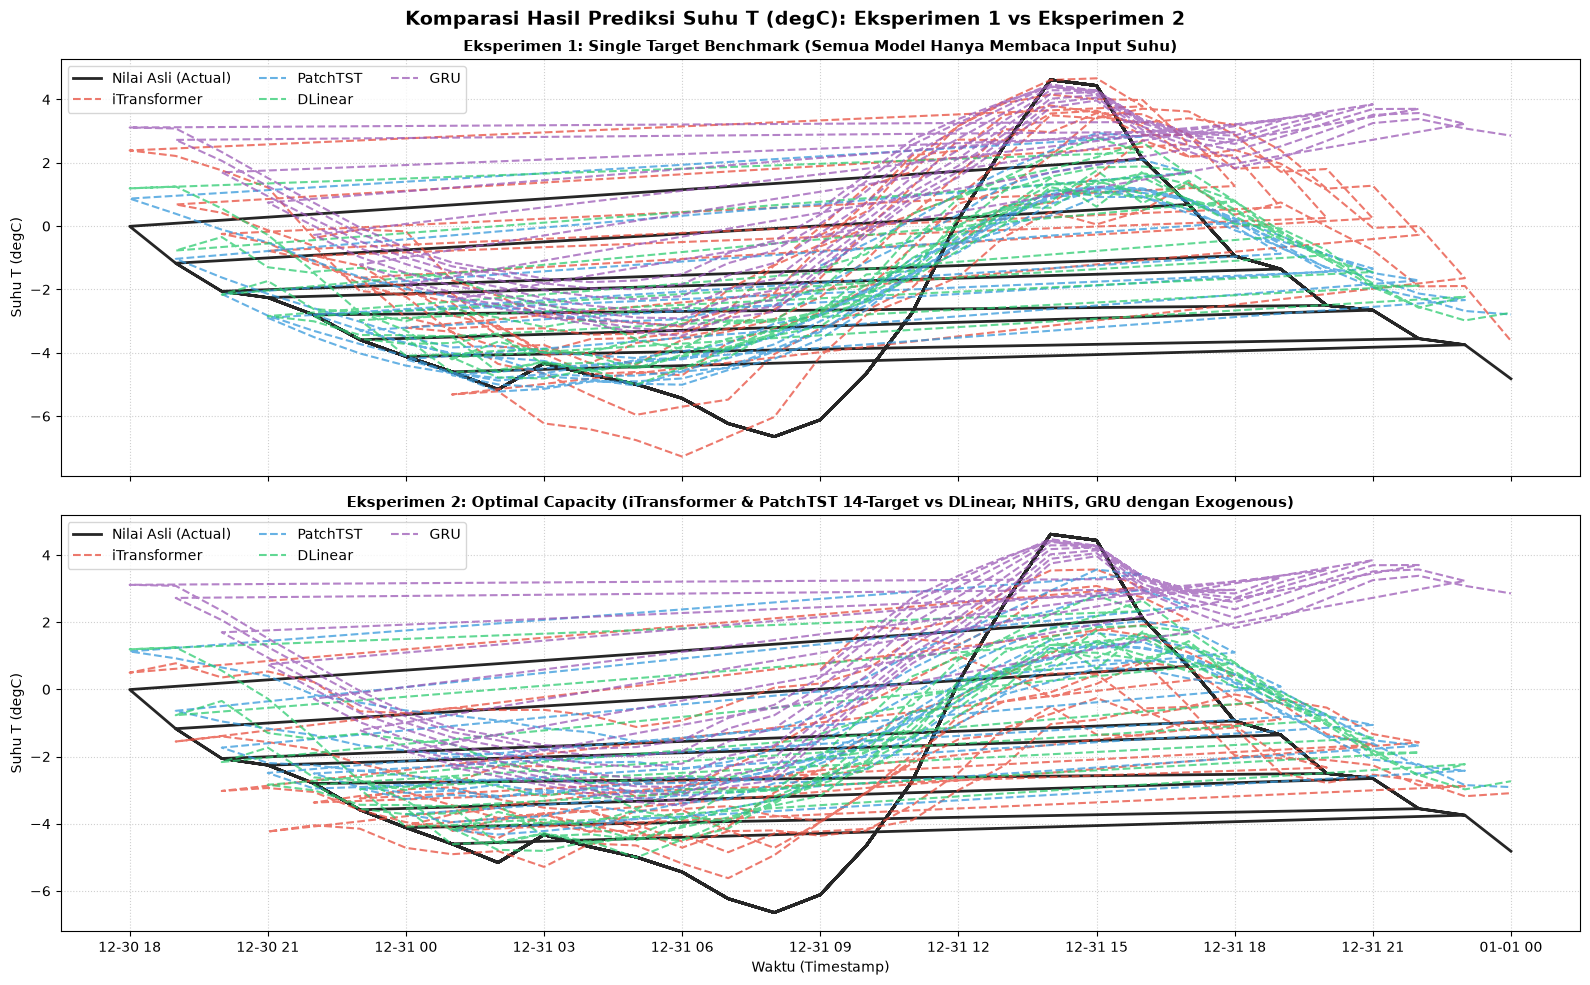

In [7]:
import matplotlib.pyplot as plt

# 1. Filter khusus target 'T (degC)' dan ambil 200 timestep terakhir untuk plot
plot_exp1 = cv_exp1[cv_exp1['unique_id'] == 'T (degC)'].tail(200)
plot_exp2 = cv_exp2[cv_exp2['unique_id'] == 'T (degC)'].tail(200)

# Warna konsisten untuk setiap model di kedua subplot
colors = {
    'iTransformer': '#e74c3c',  # Merah
    'PatchTST': '#3498db',  # Biru
    'DLinear': '#2ecc71',  # Hijau
    'NHiTS': '#f39c12',  # Oranye
    'GRU': '#9b59b6',  # Ungu
}

models = ['iTransformer', 'PatchTST', 'DLinear', 'NHiTS', 'GRU']

# 2. Buat Figure dengan 2 Subplot Vertikal
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# --- Subplot 1: Eksperimen 1 (Pure Single Target) ---
ax1.plot(
    plot_exp1['ds'],
    plot_exp1['y'],
    label='Nilai Asli (Actual)',
    color='black',
    linewidth=2,
    alpha=0.85,
)

for model in models:
  if model in plot_exp1.columns:
    ax1.plot(
        plot_exp1['ds'],
        plot_exp1[model],
        label=model,
        color=colors[model],
        linestyle='--',
        alpha=0.75,
    )

ax1.set_title(
    'Eksperimen 1: Single Target Benchmark (Semua Model Hanya Membaca Input'
    ' Suhu)',
    fontsize=11,
    fontweight='bold',
)
ax1.set_ylabel('Suhu T (degC)', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', ncol=3)

# --- Subplot 2: Eksperimen 2 (Optimal Capacity) ---
ax2.plot(
    plot_exp2['ds'],
    plot_exp2['y'],
    label='Nilai Asli (Actual)',
    color='black',
    linewidth=2,
    alpha=0.85,
)

for model in models:
  if model in plot_exp2.columns:
    ax2.plot(
        plot_exp2['ds'],
        plot_exp2[model],
        label=model,
        color=colors[model],
        linestyle='--',
        alpha=0.75,
    )

ax2.set_title(
    'Eksperimen 2: Optimal Capacity (iTransformer & PatchTST 14-Target vs'
    ' DLinear, NHiTS, GRU dengan Exogenous)',
    fontsize=11,
    fontweight='bold',
)
ax2.set_xlabel('Waktu (Timestamp)', fontsize=10)
ax2.set_ylabel('Suhu T (degC)', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left', ncol=3)

# Layout adjustment & simpan
plt.suptitle(
    'Komparasi Hasil Prediksi Suhu T (degC): Eksperimen 1 vs Eksperimen 2',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('komparasi_eksperimen_1_vs_2_suhu.png', dpi=300)
plt.show()

# **menghitung selisih persentase penurunan MAE dan RMSE (peningkatan performa) dari Eksperimen 1 ke Eksperimen 2 untuk setiap model**

In [9]:
import pandas as pd
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse

MODEL_NAMES = ['iTransformer', 'PatchTST', 'DLinear', 'NHITS', 'GRU']

# 1. Hitung Evaluasi Khusus Target 'T (degC)' untuk Kedua Eksperimen
eval_exp1 = evaluate(
    df=cv_exp1[cv_exp1['unique_id'] == 'T (degC)'],
    metrics=[mae, rmse],
    models=MODEL_NAMES,
)

eval_exp2 = evaluate(
    df=cv_exp2[cv_exp2['unique_id'] == 'T (degC)'],
    metrics=[mae, rmse],
    models=MODEL_NAMES,
)

# 2. Transformasi Struktur DataFrame (Model sebagai Row Index)
df_exp1 = eval_exp1.groupby('metric')[MODEL_NAMES].mean().T
df_exp2 = eval_exp2.groupby('metric')[MODEL_NAMES].mean().T

# 3. Hitung Persentase Peningkatan
summary_df = pd.DataFrame(index=MODEL_NAMES)

# MAE
summary_df['MAE Exp1'] = df_exp1['mae']
summary_df['MAE Exp2'] = df_exp2['mae']
summary_df['Peningkatan MAE (%)'] = (
    (df_exp1['mae'] - df_exp2['mae']) / df_exp1['mae']
) * 100

# RMSE
summary_df['RMSE Exp1'] = df_exp1['rmse']
summary_df['RMSE Exp2'] = df_exp2['rmse']
summary_df['Peningkatan RMSE (%)'] = (
    (df_exp1['rmse'] - df_exp2['rmse']) / df_exp1['rmse']
) * 100

# 4. Format Output
summary_df = summary_df.round(3)

print('=== ANALISIS DELTA PERFORMA EKSPERIMEN 1 VS EKSPERIMEN 2 ===')
print(summary_df.to_string())

=== ANALISIS DELTA PERFORMA EKSPERIMEN 1 VS EKSPERIMEN 2 ===
              MAE Exp1  MAE Exp2  Peningkatan MAE (%)  RMSE Exp1  RMSE Exp2  Peningkatan RMSE (%)
iTransformer     2.356     2.297                2.484      2.784      2.743                 1.486
PatchTST         1.990     2.202              -10.660      2.388      2.614                -9.459
DLinear          2.141     2.141                0.000      2.531      2.531                 0.000
NHITS            2.562     2.562                0.000      3.084      3.084                 0.000
GRU              3.069     3.069                0.000      3.474      3.474                 0.000
